<a href="https://colab.research.google.com/github/Tanuja781/Forest-cover-Type-Classicifier/blob/main/Forest_Cover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
%%writefile app.py
!pip install streamlit -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import streamlit as st

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

Writing app.py


In [ ]:
df = pd.read_csv("/content/covtype.csv")
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            234             238   

Cover_Type
2.0    129444
1.0     52803
5.0      3716
7.0      2160
3.0      2160
6.0      2160
4.0      2160
Name: count, dtype: int64
Missing values in Cover_Type:
1
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            1
Soil_Type3                            1
Soil_Type4                            1
Soil_Type5                            1
Soil_Type6                            1
Soil_Type7                       

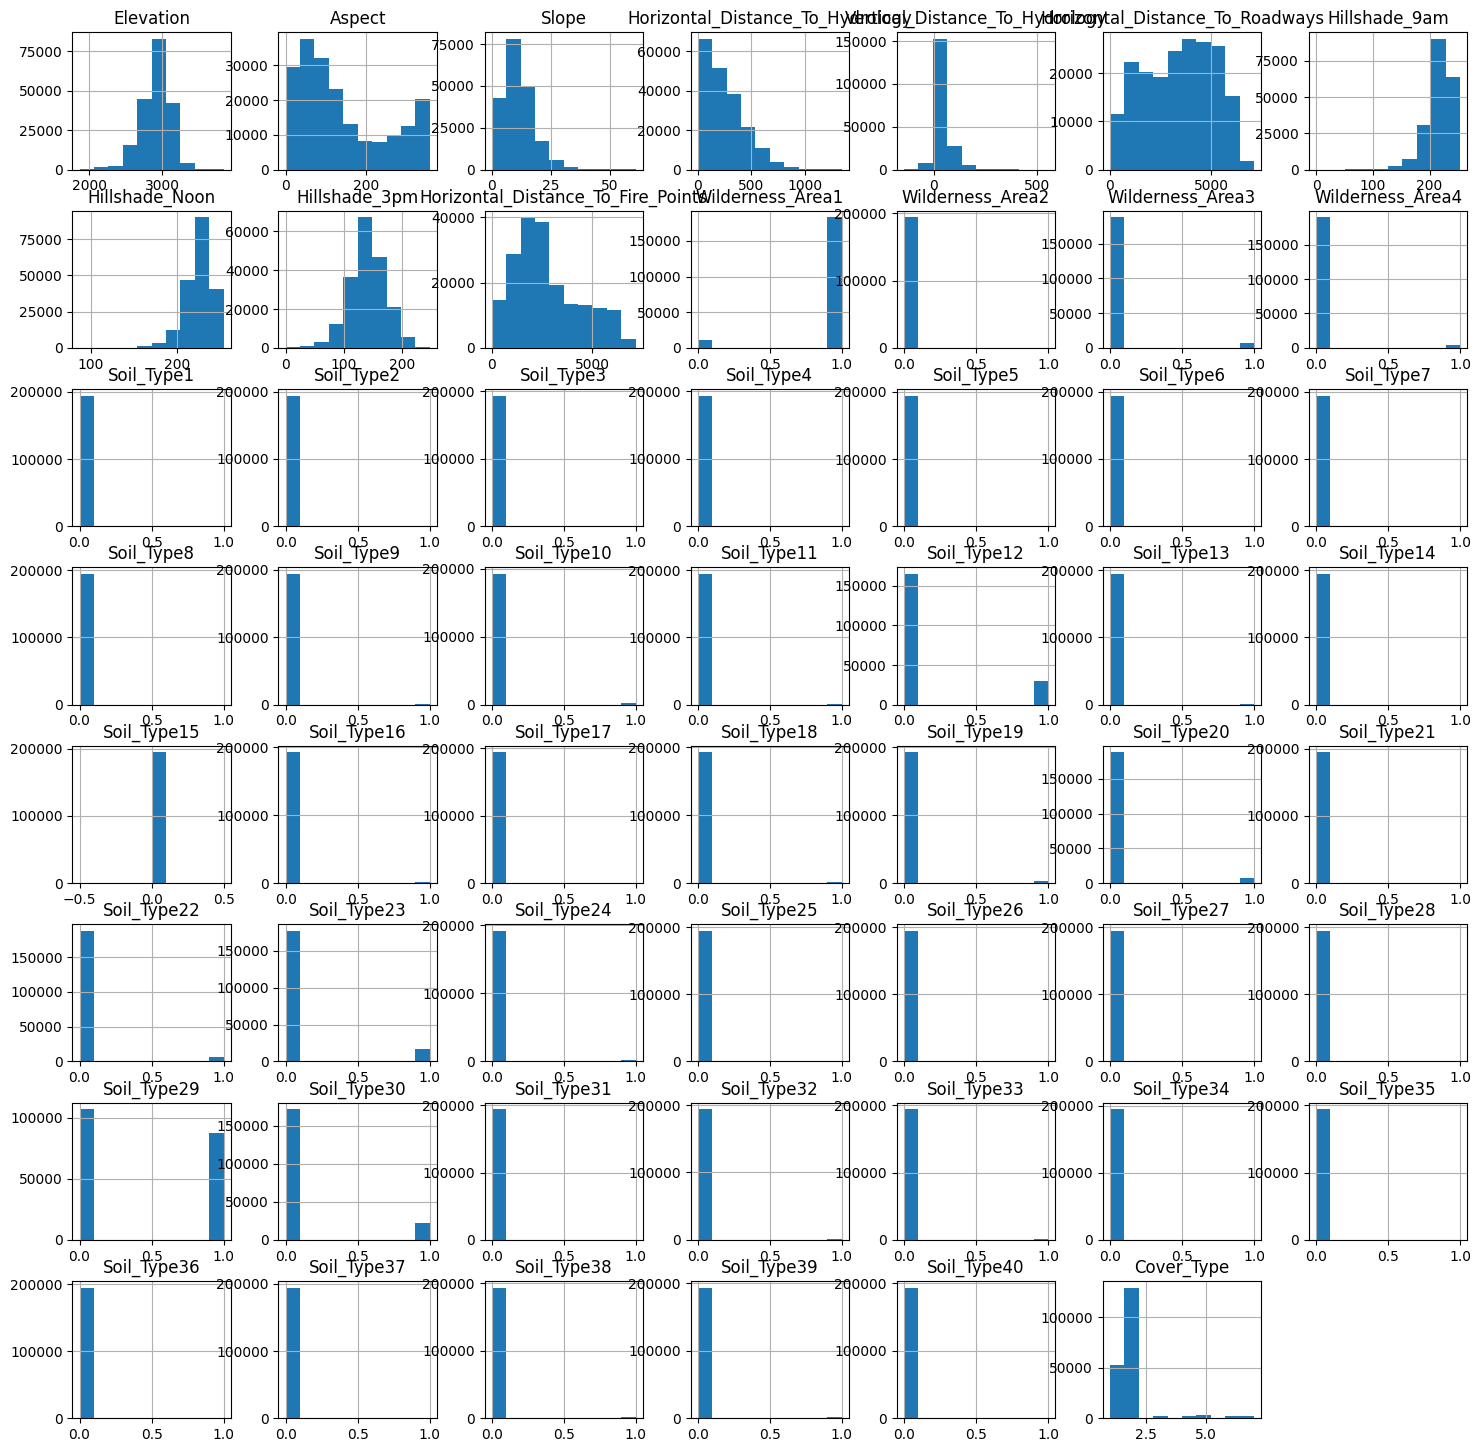

                                    Elevation    Aspect     Slope  \
Elevation                            1.000000  0.029353 -0.182449   
Aspect                               0.029353  1.000000  0.060101   
Slope                               -0.182449  0.060101  1.000000   
Horizontal_Distance_To_Hydrology     0.317572  0.014023 -0.063928   
Vertical_Distance_To_Hydrology       0.142752  0.090317  0.249172   
Horizontal_Distance_To_Roadways      0.674607  0.138621 -0.093573   
Hillshade_9am                       -0.013550 -0.564500 -0.197539   
Hillshade_Noon                       0.162014  0.346185 -0.587819   
Hillshade_3pm                        0.126781  0.619576 -0.294674   
Horizontal_Distance_To_Fire_Points   0.065447 -0.041373 -0.118030   
Wilderness_Area1                     0.293392 -0.057092 -0.228462   
Wilderness_Area2                     0.103493  0.015635  0.015836   
Wilderness_Area3                     0.006417  0.035252  0.113012   
Wilderness_Area4                  

In [ ]:
print(df["Cover_Type"].value_counts())
print("Missing values in Cover_Type:")
print(df["Cover_Type"].isnull().sum())
print(df.isnull().sum())
print("Total Missing Values:")
print(df.isnull().sum().sum())
df.hist(figsize=(18,18))
plt.show()
print(df.corr())

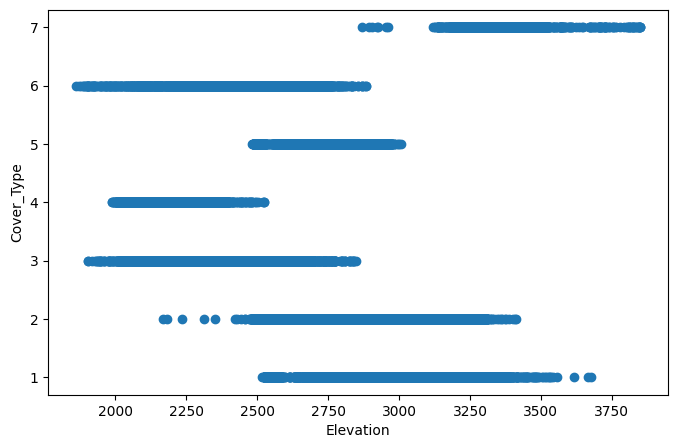

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Elevation"], df["Cover_Type"])
plt.xlabel("Elevation")
plt.ylabel("Cover_Type")
plt.show()

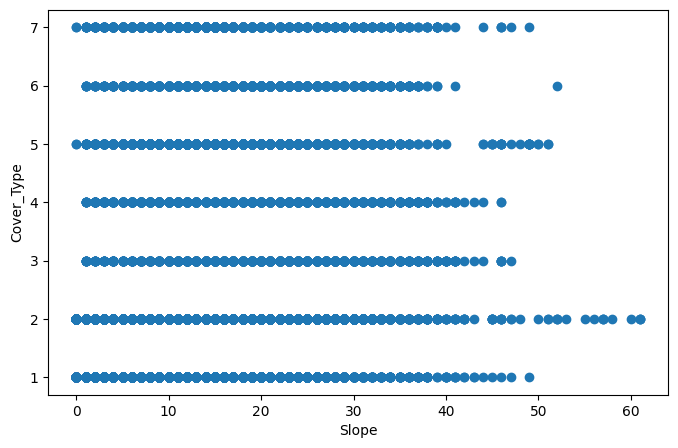

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Slope"], df["Cover_Type"])
plt.xlabel("Slope")
plt.ylabel("Cover_Type")
plt.show()

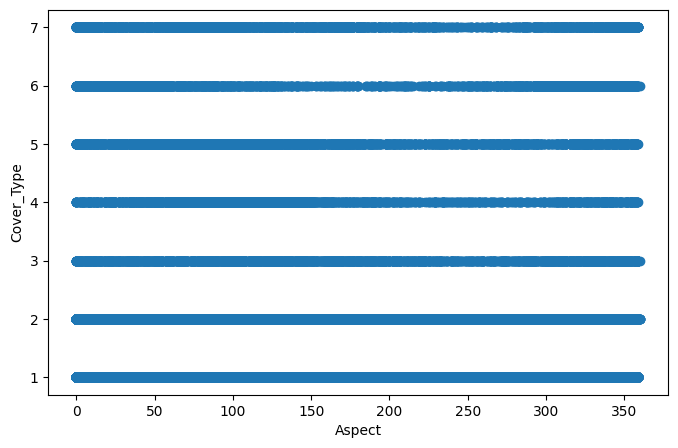

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Aspect"], df["Cover_Type"])
plt.xlabel("Aspect")
plt.ylabel("Cover_Type")
plt.show()

In [ ]:
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]
print(X.shape)
print(y.shape)

(194604, 54)
(194604,)


In [ ]:
print("NaN values in y:", y.isna().sum())
print("Total NaN values in X:", X.isna().sum().sum())
print(y.head())
print(y.tail())
print(y.dtype)
df = df.dropna(subset=["Cover_Type"])
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

NaN values in y: 1
Total NaN values in X: 39
0    5.0
1    5.0
2    2.0
3    2.0
4    5.0
Name: Cover_Type, dtype: float64
194599    2.0
194600    2.0
194601    2.0
194602    2.0
194603    NaN
Name: Cover_Type, dtype: float64
float64
(155682, 54)
(38921, 54)
(155682,)
(38921,)


In [ ]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9452


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

         1.0       0.95      0.88      0.91     10561
         2.0       0.95      0.98      0.96     25889
         3.0       0.83      0.81      0.82       432
         4.0       0.91      0.97      0.94       432
         5.0       0.91      0.80      0.85       743
         6.0       0.83      0.85      0.84       432
         7.0       0.95      0.95      0.95       432

    accuracy                           0.95     38921
   macro avg       0.90      0.89      0.90     38921
weighted avg       0.95      0.95      0.94     38921


Confusion Matrix:

[[ 9279  1253     0     0    12     0    17]
 [  449 25367    14     0    42    12     5]
 [    0     0   352    25     6    49     0]
 [    0     0     8   418     0     6     0]
 [    7   131     4     0   595     6     0]
 [    0     1    48    14     0   369     0]
 [   22     0     0     0     1     0   409]]


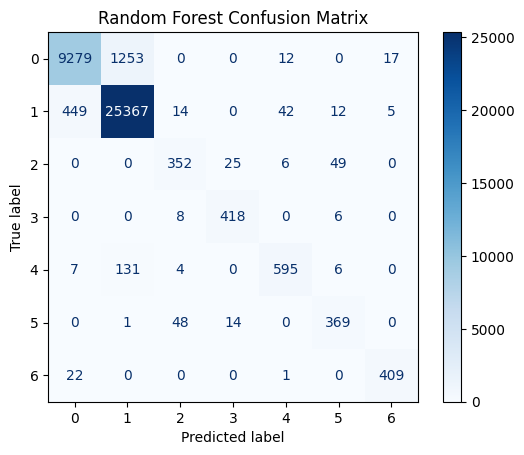

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_tuned.fit(X_train, y_train)
y_pred_tuned = rf_tuned.predict(X_test)

In [ ]:
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Model Accuracy: 0.9289329667788597

Classification Report:

              precision    recall  f1-score   support

         1.0       0.95      0.82      0.88     10561
         2.0       0.93      0.98      0.95     25889
         3.0       0.82      0.81      0.81       432
         4.0       0.90      0.97      0.94       432
         5.0       0.89      0.75      0.81       743
         6.0       0.83      0.84      0.84       432
         7.0       0.94      0.91      0.93       432

    accuracy                           0.93     38921
   macro avg       0.90      0.87      0.88     38921
weighted avg       0.93      0.93      0.93     38921


Confusion Matrix:

[[ 8694  1831     0     0    14     1    21]
 [  436 25378    13     0    47    12     3]
 [    0     0   350    30     5    47     0]
 [    0     0     7   419     0     6     0]
 [    7   168     5     0   556     7     0]
 [    0     0    52    14     1   365     0]
 [   38     0     0     0     1     0   393]]


In [ ]:
baseline_accuracy = accuracy_score(y_test, y_pred)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print("Baseline Accuracy :", baseline_accuracy)
print("Tuned Accuracy    :", tuned_accuracy)
if tuned_accuracy > baseline_accuracy:
    print("\nThe tuned Random Forest model performed better.")
elif tuned_accuracy == baseline_accuracy:
    print("\nBoth models achieved the same accuracy.")
else:
    print("\nThe baseline Random Forest model performed better.")

Baseline Accuracy : 0.94522237352586
Tuned Accuracy    : 0.9289329667788597

The baseline Random Forest model performed better.


In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

In [ ]:
print("Gradient Boosting Accuracy:")
print(accuracy_score(y_test, gb_pred))
print("\nClassification Report:")
print(classification_report(y_test, gb_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

Gradient Boosting Accuracy:
0.8357698928598957

Classification Report:
              precision    recall  f1-score   support

         1.0       0.79      0.63      0.70     10561
         2.0       0.85      0.93      0.89     25889
         3.0       0.70      0.73      0.71       432
         4.0       0.89      0.95      0.92       432
         5.0       0.78      0.60      0.68       743
         6.0       0.74      0.71      0.72       432
         7.0       0.91      0.86      0.88       432

    accuracy                           0.84     38921
   macro avg       0.81      0.77      0.79     38921
weighted avg       0.83      0.84      0.83     38921


Confusion Matrix:
[[ 6629  3871     0     0    26     2    33]
 [ 1720 24050    13     0    80    22     4]
 [    0     0   315    39    10    68     0]
 [    0     0    13   411     0     8     0]
 [   16   258    12     0   448     9     0]
 [    0     2    99    14    11   306     0]
 [   61     0     0     0     1     0   370

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)
print("Random Forest Accuracy :", rf_accuracy)
print("Gradient Boosting Accuracy :", gb_accuracy)
if rf_accuracy > gb_accuracy:
    print("Random Forest performed better.")
else:
    print("Gradient Boosting performed better.")
best_model = rf_model if rf_accuracy >= gb_accuracy else gb_model

Random Forest Accuracy : 0.94522237352586
Gradient Boosting Accuracy : 0.8357698928598957
Random Forest performed better.


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance.head(15)

,Feature,Importance
0,Elevation,0.233549
5,Horizontal_Distance_To_Roadways,0.150231
9,Horizontal_Distance_To_Fire_Points,0.125514
4,Vertical_Distance_To_Hydrology,0.063536
3,Horizontal_Distance_To_Hydrology,0.062592
1,Aspect,0.049496
7,Hillshade_Noon,0.046405
8,Hillshade_3pm,0.045469
6,Hillshade_9am,0.041789
10,Wilderness_Area1,0.033748


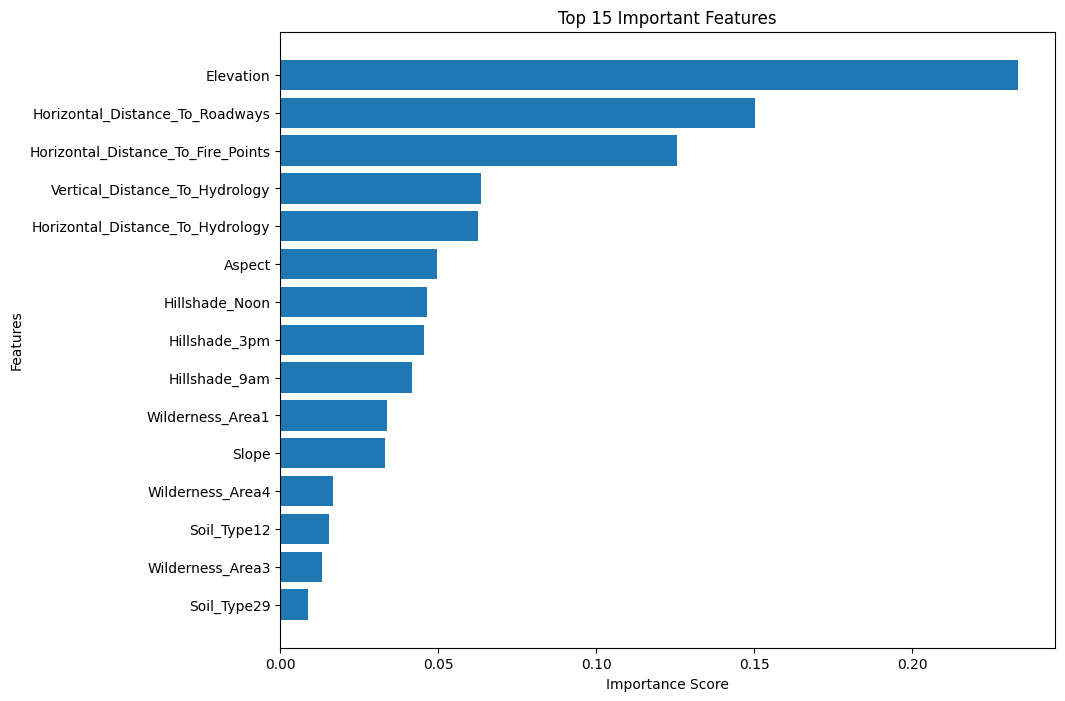

In [ ]:
plt.figure(figsize=(10,8))
plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
joblib.dump(best_model, "forest_cover_classifier.pkl")
print("Model saved successfully.")
loaded_model = joblib.load("forest_cover_classifier.pkl")
print("Model loaded successfully.")

Model saved successfully.
Model loaded successfully.


In [ ]:
sample = X_test.iloc[[0]]
prediction = loaded_model.predict(sample)
print("Actual Class :", y_test.iloc[0])
print("Predicted Class :", prediction[0])

Actual Class : 1.0
Predicted Class : 1.0


In [ ]:
sample_data = X_test.iloc[:5]
predictions = loaded_model.predict(sample_data)
results = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": predictions
})
results

,Actual,Predicted
0,1.0,1.0
1,2.0,2.0
2,2.0,2.0
3,1.0,1.0
4,1.0,1.0


In [ ]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

In [ ]:
print("Cross Validation Scores")
print(cv_scores)
print("\nAverage Accuracy:")
print(cv_scores.mean())
print("\nStandard Deviation:")
print(cv_scores.std())

Cross Validation Scores
[0.69178593 0.8064541  0.78813494 0.66816547 0.62795478]

Average Accuracy:
0.7164990422663685

Standard Deviation:
0.06929729182817533


In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [20, 30, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=1,
             param_grid={'max_depth': [20, 30, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [ ]:
print("Best Parameters")
print(grid_search.best_params_)
print("\nBest Accuracy")
print(grid_search.best_score_)

Best Parameters
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Accuracy
0.9359848922804178


In [ ]:
best_rf = grid_search.best_estimator_
best_prediction = best_rf.predict(X_test)
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,best_prediction))

0.9459417795020683


In [ ]:
print(classification_report(
    y_test,
    best_prediction
))
cm = confusion_matrix(
    y_test,
    best_prediction
)

print(cm)

              precision    recall  f1-score   support

         1.0       0.95      0.88      0.91     10561
         2.0       0.95      0.98      0.96     25889
         3.0       0.84      0.82      0.83       432
         4.0       0.92      0.98      0.95       432
         5.0       0.90      0.80      0.85       743
         6.0       0.85      0.87      0.86       432
         7.0       0.95      0.94      0.94       432

    accuracy                           0.95     38921
   macro avg       0.91      0.89      0.90     38921
weighted avg       0.95      0.95      0.95     38921

[[ 9278  1250     0     0    14     0    19]
 [  428 25389    14     0    43    11     4]
 [    0     0   356    25     6    45     0]
 [    0     0     5   422     0     5     0]
 [    7   132     4     0   594     6     0]
 [    0     1    43    14     0   374     0]
 [   27     0     0     0     1     0   404]]


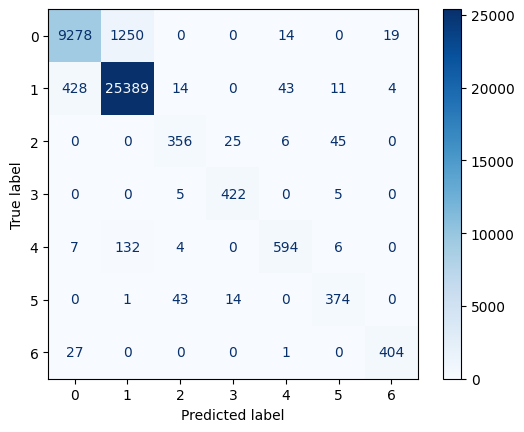

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")

In [ ]:
joblib.dump(best_rf, "forest_cover_classifier.pkl")
print("Model saved successfully.")
loaded_model = joblib.load("forest_cover_classifier.pkl")
print("Model loaded successfully.")
sample = X_test.iloc[[0]]
prediction = loaded_model.predict(sample)
print("Predicted Forest Cover Type:", prediction[0])

Model saved successfully.
Model loaded successfully.
Predicted Forest Cover Type: 1.0


In [ ]:
print("Actual Class:", y_test.iloc[0])
print("Predicted Class:", prediction[0])
predictions = loaded_model.predict(X_test.iloc[:10])
comparison = X_test.iloc[:10].copy()
comparison["Actual"] = y_test.iloc[:10].values
comparison["Predicted"] = predictions
comparison[["Actual", "Predicted"]]

Actual Class: 1.0
Predicted Class: 1.0


,Actual,Predicted
146950,1.0,1.0
39506,2.0,2.0
128977,2.0,2.0
179722,1.0,1.0
9181,1.0,1.0
157242,2.0,2.0
64749,2.0,2.0
84539,2.0,2.0
15011,3.0,6.0
73810,2.0,2.0


In [ ]:
st.set_page_config(
    page_title="Forest Cover Type Classifier",
    page_icon="🌲"
)
st.title("🌲 Forest Cover Type Classifier")
st.write("Predict the forest cover type using cartographic features.")

2026-07-22 09:52:52.799 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:52.802 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:53.020 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-22 09:52:53.021 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:53.023 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:53.026 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:53.027 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
elevation = st.number_input("Elevation", value=2500)
aspect = st.number_input("Aspect", value=100)
slope = st.number_input("Slope", value=10)
horizontal_distance_to_hydrology = st.number_input(
    "Horizontal Distance To Hydrology",
    value=150
)
vertical_distance_to_hydrology = st.number_input(
    "Vertical Distance To Hydrology",
    value=20
)
horizontal_distance_to_roadways = st.number_input(
    "Horizontal Distance To Roadways",
    value=1000
)
hillshade_9am = st.number_input("Hillshade 9am", value=220)
hillshade_noon = st.number_input("Hillshade Noon", value=230)
hillshade_3pm = st.number_input("Hillshade 3pm", value=140)
horizontal_distance_to_fire_points = st.number_input(
    "Horizontal Distance To Fire Points",
    value=1200
)
st.button("Predict")

2026-07-22 09:52:53.037 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:53.039 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:53.040 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:53.042 Session state does not function when running a script without `streamlit run`
2026-07-22 09:52:53.043 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:53.045 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:53.046 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:53.047 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52

False

In [ ]:
test_predictions = best_rf.predict(X_test)
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": test_predictions
})

results.head(10)

,Actual,Predicted
0,1.0,1.0
1,2.0,2.0
2,2.0,2.0
3,1.0,1.0
4,1.0,1.0
5,2.0,2.0
6,2.0,2.0
7,2.0,2.0
8,3.0,6.0
9,2.0,2.0


In [ ]:
results["Correct Prediction"] = (
    results["Actual"] == results["Predicted"]
)

results.head(10)

,Actual,Predicted,Correct Prediction
0,1.0,1.0,True
1,2.0,2.0,True
2,2.0,2.0,True
3,1.0,1.0,True
4,1.0,1.0,True
5,2.0,2.0,True
6,2.0,2.0,True
7,2.0,2.0,True
8,3.0,6.0,False
9,2.0,2.0,True


In [ ]:
prediction_accuracy = (
    results["Correct Prediction"].mean() * 100
)

print(f"Prediction Accuracy: {prediction_accuracy:.2f}%")

Prediction Accuracy: 94.59%


In [ ]:
incorrect_predictions = results[
    results["Correct Prediction"] == False
]

incorrect_predictions.head(10)

,Actual,Predicted,Correct Prediction
8,3.0,6.0,False
38,5.0,3.0,False
53,2.0,1.0,False
87,1.0,2.0,False
98,2.0,1.0,False
120,3.0,4.0,False
140,1.0,2.0,False
155,2.0,3.0,False
180,7.0,1.0,False
182,1.0,2.0,False


In [ ]:
print("Correct Predictions:",
      results["Correct Prediction"].sum())

print("Incorrect Predictions:",
      len(results) - results["Correct Prediction"].sum())

Correct Predictions: 36817
Incorrect Predictions: 2104


In [ ]:
st.set_page_config(
    page_title="Forest Cover Type Classifier",
    page_icon="🌲",
    layout="wide"
)

2026-07-22 09:52:55.737 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
model = joblib.load("forest_cover_classifier.pkl")
st.title("🌲 Forest Cover Type Classifier")
st.markdown("""
This application predicts the **Forest Cover Type**
using cartographic features from the UCI Forest CoverType dataset.
""")

2026-07-22 09:52:57.238 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.239 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.241 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.242 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.244 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.245 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
st.sidebar.header("Project Information")
st.sidebar.write("Machine Learning Project")
st.sidebar.write("Model: Random Forest Classifier")
st.sidebar.write("Dataset: UCI Forest CoverType")

2026-07-22 09:52:57.257 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.259 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.260 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.262 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.263 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.263 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.265 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.266 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
st.header("Enter Cartographic Features")
elevation = st.number_input(
    "Elevation",
    min_value=0,
    value=2500
)

aspect = st.number_input(
    "Aspect",
    min_value=0,
    max_value=360,
    value=100
)

slope = st.number_input(
    "Slope",
    min_value=0,
    max_value=90,
    value=15
)
st.button("Predict")

2026-07-22 09:52:57.278 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.278 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.280 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.283 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.284 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.285 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.287 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.288 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

False

In [ ]:
input_data = pd.DataFrame({
    "Elevation": [elevation],
    "Aspect": [aspect],
    "Slope": [slope],
    "Horizontal_Distance_To_Hydrology": [horizontal_distance_to_hydrology],
    "Vertical_Distance_To_Hydrology": [vertical_distance_to_hydrology],
    "Horizontal_Distance_To_Roadways": [horizontal_distance_to_roadways],
    "Hillshade_9am": [hillshade_9am],
    "Hillshade_Noon": [hillshade_noon],
    "Hillshade_3pm": [hillshade_3pm],
    "Horizontal_Distance_To_Fire_Points": [horizontal_distance_to_fire_points]
})

In [ ]:
if st.button("Predict Forest Cover Type"):
    prediction = model.predict(input_data)
    st.success(
        f"🌲 Predicted Forest Cover Type: **{prediction[0]}**"
    )

2026-07-22 09:52:57.322 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.326 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.327 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.328 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 09:52:57.329 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [49]:
st.sidebar.markdown("---")
st.sidebar.subheader("About")

st.sidebar.info(
    """
    **Forest Cover Type Classifier**

    Machine Learning Internship Project

    Algorithms:
    - Random Forest
    - Gradient Boosting

    Framework:
    - Streamlit
    """
)

2026-07-22 10:00:26.419 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:00:26.421 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:00:26.423 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:00:26.425 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:00:26.426 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:00:26.428 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:00:26.429 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:00:26.430 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator(_root_container=1, _parent=DeltaGenerator())

In [51]:
with st.expander("View Entered Features"):

    st.dataframe(input_data)
st.markdown("---")
st.caption(
    "Developed using Python, Scikit-learn, and Streamlit."
)

2026-07-22 10:02:41.453 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:41.525 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:41.528 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:41.530 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:41.532 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:41.536 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:41.539 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:41.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [52]:
st.subheader("Model Details")
st.write("Selected Model: Random Forest Classifier")
st.write("Dataset: UCI Forest CoverType Dataset")

2026-07-22 10:02:59.829 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:59.831 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:59.832 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:59.833 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:59.835 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:59.835 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:59.837 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 10:02:59.838 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
!streamlit run app.py



2026-07-22 10:14:29.249 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.75.176.162:8501

